In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ptyrad.analysis import Analyzer

In [2]:
from tifffile import imread, imwrite

In [3]:
import hyperspy.api as hs

In [4]:
import colorcet as cc

In [25]:
from scipy.ndimage import rotate

In [5]:
%matplotlib widget

In [6]:
# Change this to the ABSOLUTE PATH to the ptyrad/ folder so you can correctly access data/ and params/
work_dir = '/Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 100/ds8'

os.chdir(work_dir)
print("Current working dir: ", os.getcwd())
# The printed working dir should be ".../ptyrad/" to locate the example params files easily

Current working dir:  /Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 100/ds8


In [7]:
model_path = '/Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 100/ds8/3_load_pos_long_run_5A_slice_large_batch_small_step/20260921_full_N24000_dp128_flipT100_random128_p6_1obj_60slice_dz5/model_iter2000.hdf5'
analyzer = Analyzer(model_path)
print(analyzer)

Analyzer(source='/Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 100/ds8/3_load_pos_long_run_5A_slice_large_batch_small_step/20260921_full_N24000_dp128_flipT100_random128_p6_1obj_60slice_dz5/model_iter2000.hdf5', niter=2000, obj=(omode=1, nslice=60), probe=(pmode=6, shape=(128, 128)))


In [8]:
print("Top-level keys:")
for k in analyzer.data.keys():
    print(" ", k)

Top-level keys:
  avg_iter_t
  avg_losses
  avg_tilt_iters
  batch_losses
  convergence_iters
  dz_iters
  indices
  iter_times
  loss_iters
  lr_iters
  model_attributes
  niter
  optim_state_dict
  optimizable_tensors
  output_path
  params
  ptyrad_version
  random_seed
  scheduler_state_dict


In [9]:
# Full dotted-key listing of every array stored in the HDF5
print("\n".join(analyzer.get_keys()))

avg_iter_t
avg_losses.loss_pacbed
avg_losses.loss_poissn
avg_losses.loss_simlar
avg_losses.loss_single
avg_losses.loss_sparse
avg_tilt_iters.niter
avg_tilt_iters.tilt_x
avg_tilt_iters.tilt_y
batch_losses.loss_pacbed
batch_losses.loss_poissn
batch_losses.loss_simlar
batch_losses.loss_single
batch_losses.loss_sparse
convergence_iters.obja_bg
convergence_iters.obja_fg
convergence_iters.objp_bg
convergence_iters.objp_fg
convergence_iters.probe
convergence_iters.probe_pos_shifts
dz_iters
indices
iter_times
loss_iters
lr_iters.niter
lr_iters.obj_tilts
lr_iters.obja
lr_iters.objp
lr_iters.probe
lr_iters.probe_pos_shifts
model_attributes.H
model_attributes.N_scan_fast
model_attributes.N_scan_slow
model_attributes.crop_pos
model_attributes.detector_blur_std
model_attributes.dk
model_attributes.dx
model_attributes.lambd
model_attributes.lr_params.obj_tilts
model_attributes.lr_params.obja
model_attributes.lr_params.objp
model_attributes.lr_params.probe
model_attributes.lr_params.probe_pos_shifts


In [9]:
analyzer.data['params']['init_params']['pos_params']

'2_load_pos_long_run_5A_slice/20260920_full_N24000_dp128_flipT100_random32_p6_1obj_70slice_dz5/model_iter1000.hdf5'

In [10]:
print(f'model_attributes:\n  {list(analyzer.model_attrs.keys())}\n')
print(f'optimizable_tensors:\n  {list(analyzer.opt_tensors.keys())}\n')
print(f'params:\n  {list(analyzer.params.keys())}\n')

model_attributes:
  ['H', 'N_scan_fast', 'N_scan_slow', 'crop_pos', 'detector_blur_std', 'dk', 'dx', 'lambd', 'lr_params', 'meas_Npix', 'omode_occu', 'probe_int_sum', 'scan_affine', 'simu_Npix', 'simu_match_mode', 'slice_thickness', 'start_iter', 'tilt_obj']

optimizable_tensors:
  ['obj_tilts', 'obja', 'objp', 'probe', 'probe_pos_shifts', 'slice_thickness']

params:
  ['constraint_params', 'hypertune_params', 'init_params', 'loss_params', 'model_params', 'params_path', 'recon_params']



In [11]:
# Convenient scalar properties derived from model_attributes and optimizable_tensors
print(f"Real-space pixel size  dx    = {analyzer.dx:.4f} Å")
print(f"Probe modes  pmode           = {analyzer.pmode}")
print(f"Object modes omode           = {analyzer.omode}")
print(f"Z-slices     nslice          = {analyzer.nslice}")
print(f"Multislice?                  = {analyzer.is_multislice}")
print(f"Saved at iteration           = {analyzer.niter}")

Real-space pixel size  dx    = 0.2630 Å
Probe modes  pmode           = 6
Object modes omode           = 1
Z-slices     nslice          = 60
Multislice?                  = True
Saved at iteration           = 2000


In [12]:
#analyzer.plot_dashboard()||

In [13]:
obja = analyzer.get_object_amplitude(fov='crop')
objp = analyzer.get_object_phase(fov='crop')
print("Object shape (omode, Nz, Ny, Nx):", obja.shape)

Object shape (omode, Nz, Ny, Nx): (1, 60, 475, 713)


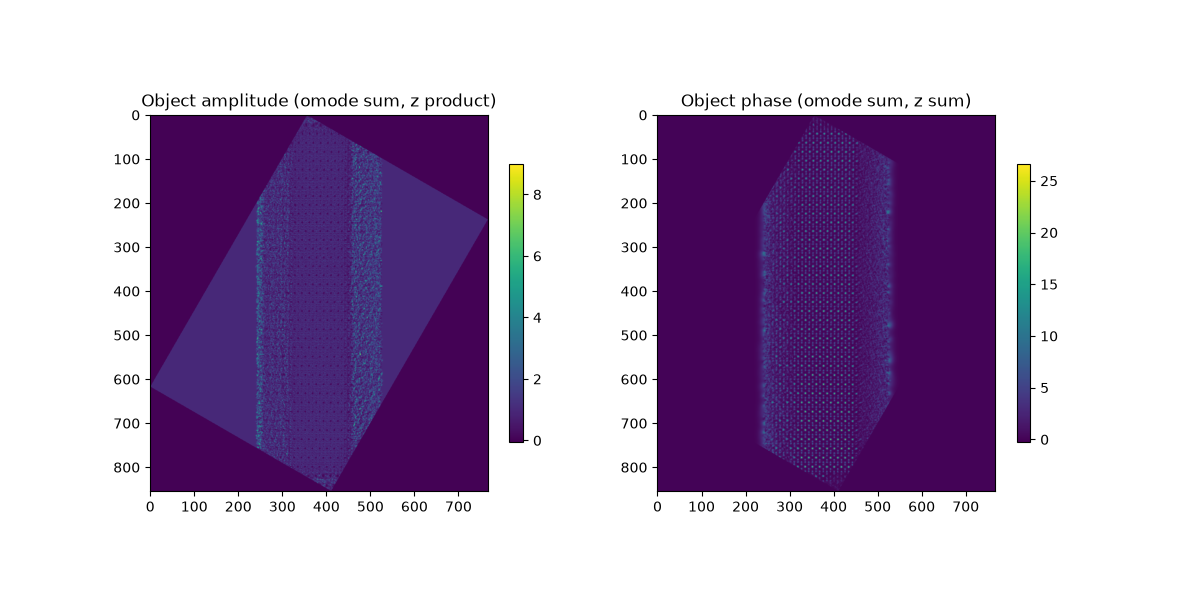

In [27]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
im0 = axs[0].imshow(rotate(obja.sum(0).prod(0), 60, reshape=True))
im1 = axs[1].imshow(rotate(objp.sum(0).sum(0), 60, reshape=True))
fig.colorbar(im0, shrink=0.6)
fig.colorbar(im1, shrink=0.6)
axs[0].set_title('Object amplitude (omode sum, z product)')
axs[1].set_title('Object phase (omode sum, z sum)')
plt.show()
# Amplitude is multiplicative along depth (transmission product); phase is additive (phase sum).

In [15]:
pos = analyzer.get_probe_positions(target='crop')
print("Positions shape (N_scan, 2) [y, x]:", pos.shape)

Positions shape (N_scan, 2) [y, x]: (24000, 2)


In [16]:
c = np.arange(10000)
s = np.arange(10000)*1e-3

/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_22102/3292146028.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(pos[:, 0], pos[:, 1], s = 3, color = 'tomato', label = 'After Optimization', cmap = 'Reds')


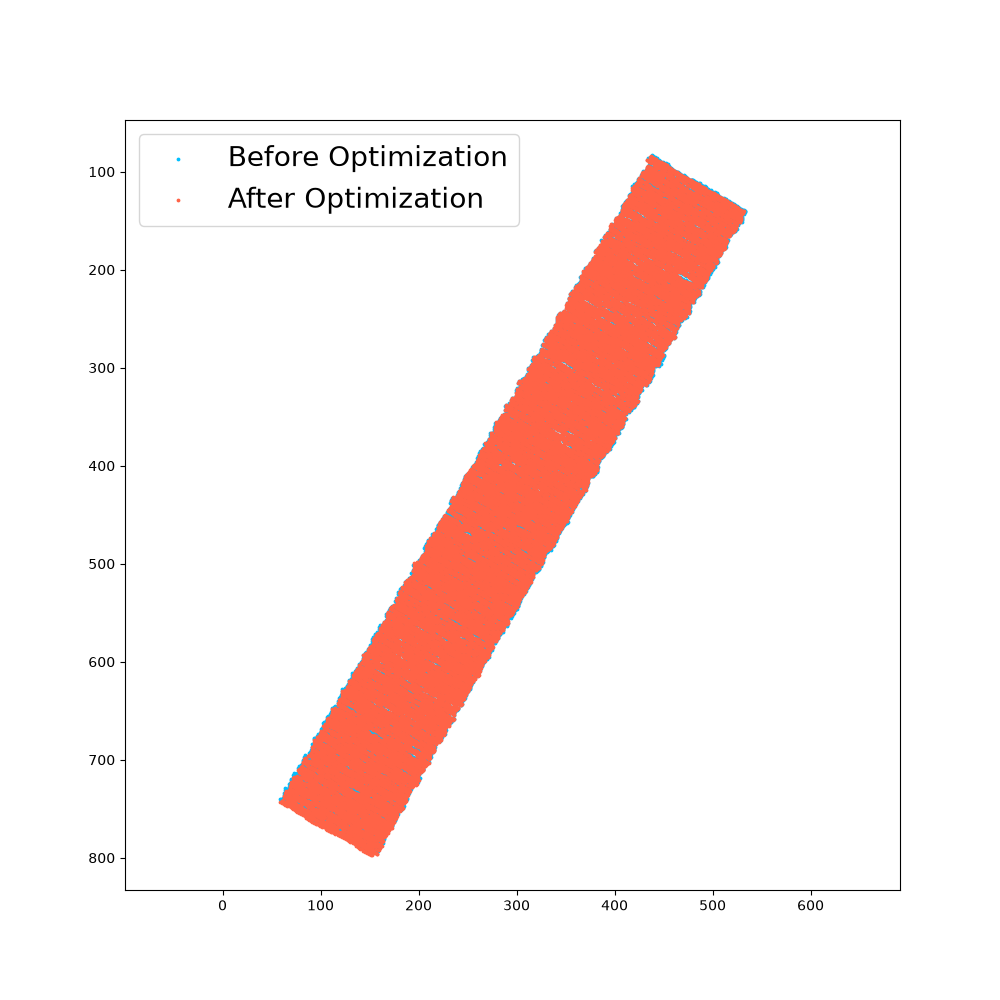

In [17]:
plt.figure(figsize = (10, 10))
plt.scatter(analyzer.data['model_attributes']['crop_pos'][:, 0], analyzer.data['model_attributes']['crop_pos'][:, 1], s = 3, color = 'deepskyblue', label = 'Before Optimization')
plt.scatter(pos[:, 0], pos[:, 1], s = 3, color = 'tomato', label = 'After Optimization', cmap = 'Reds')
#plt.quiver(analyzer.data['model_attributes']['crop_pos'][:, 0], 
#           analyzer.data['model_attributes']['crop_pos'][:, 1], 
#           pos[:, 0]-analyzer.data['model_attributes']['crop_pos'][:, 0], 
#           pos[:, 1]-analyzer.data['model_attributes']['crop_pos'][:, 1], 
#           angles='xy', scale_units='xy', scale=0.2, color='k', alpha=1, label = 'Displacement', pivot = 'middle')
plt.axis('equal')
plt.gca().invert_yaxis()
plt.legend(fontsize = 20)
plt.savefig(os.path.join(work_dir, 'probe_positions.png'), dpi = 300)

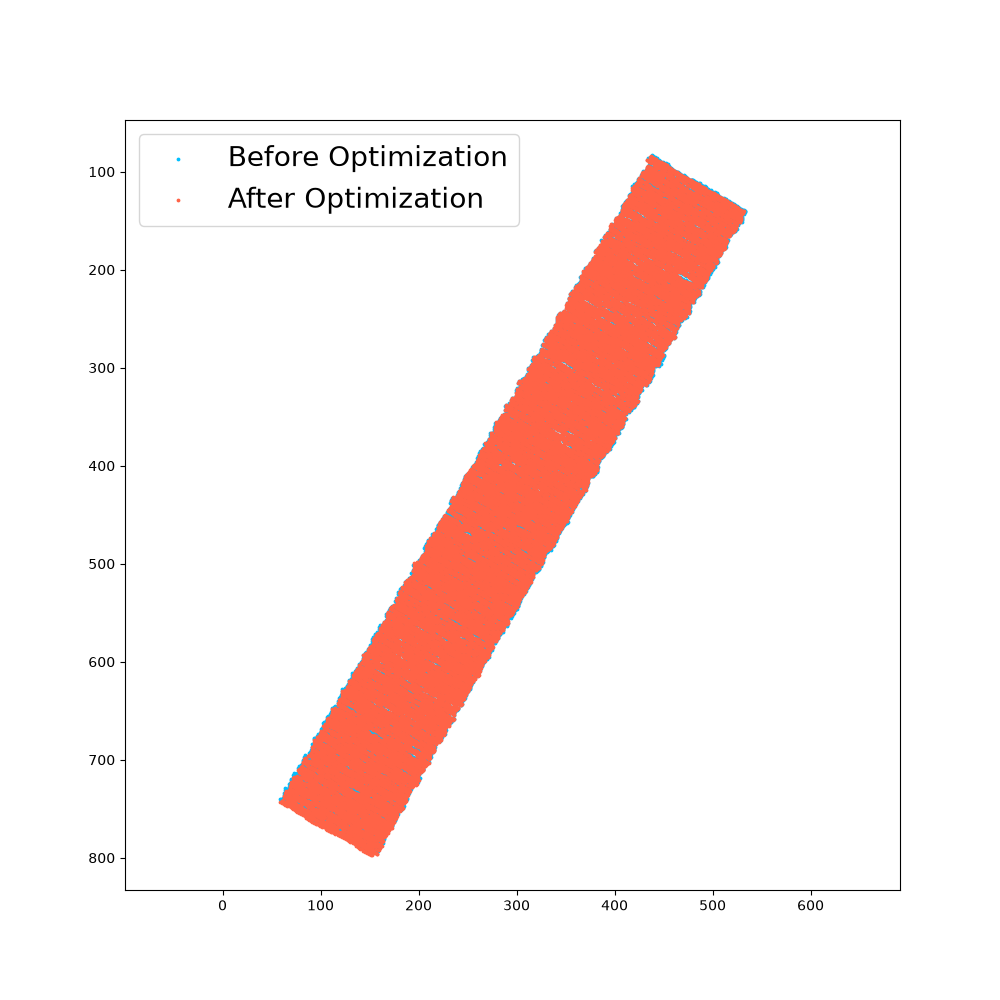

In [18]:
displacement = pos - analyzer.data['model_attributes']['crop_pos']
np.linalg.norm(displacement, axis=1).mean()*0.2630,np.linalg.norm(displacement, axis=1).max()*0.2630
plt.show()

In [30]:
imwrite(os.path.join(work_dir,"object_amplitude.tif"), rotate(obja.sum(0).astype(np.float32), 60, axes = (2,1,),reshape=True))
imwrite(os.path.join(work_dir,"object_phase.tif"), rotate(objp.sum(0), 60, axes = (2,1),reshape=True).astype(np.float32))

In [20]:
probe = analyzer.get_probe(space='real')
print("Probe shape (pmode, Ny, Nx):", probe.shape)

Probe shape (pmode, Ny, Nx): (6, 128, 128)


In [21]:
help(analyzer.plot_probe)

Help on method plot_probe in module ptyrad.analysis.analyzer:

plot_probe(
    space: Literal['real', 'fourier'] = 'real',
    amp_or_phase: Literal['amplitude', 'phase'] = 'amplitude',
    **kw
) method of ptyrad.analysis.analyzer.Analyzer instance
    Plot probe modes via :func:`ptyrad.plotting.plot_probe_modes`.

    ``space`` and ``amp_or_phase`` map directly to that function's
    ``real_or_fourier`` and ``amp_or_phase`` arguments.



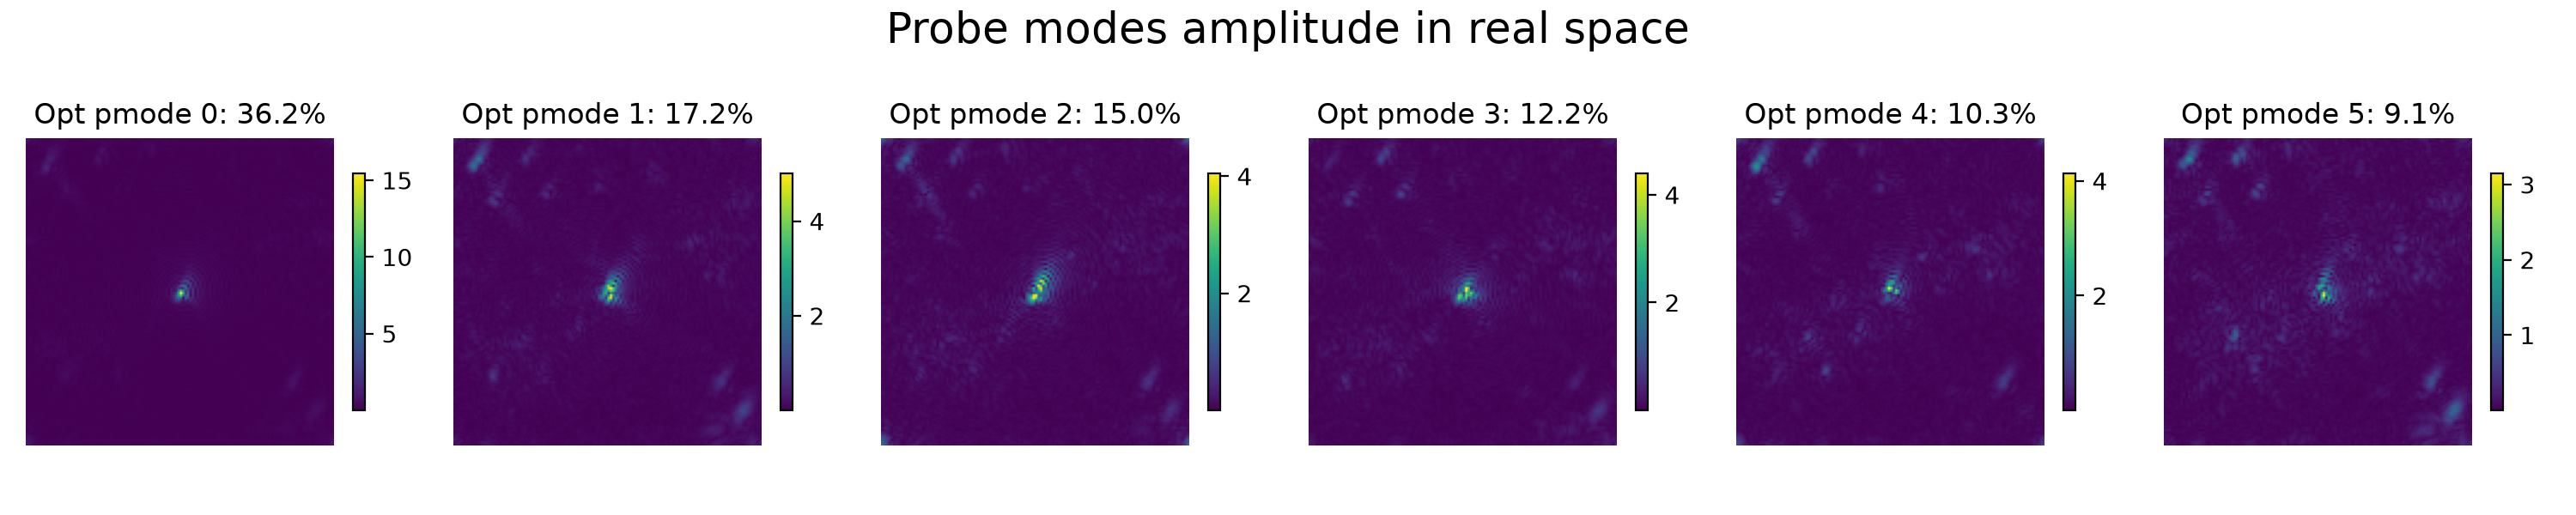

In [22]:
analyzer.plot_probe(space='real',    amp_or_phase='amplitude')

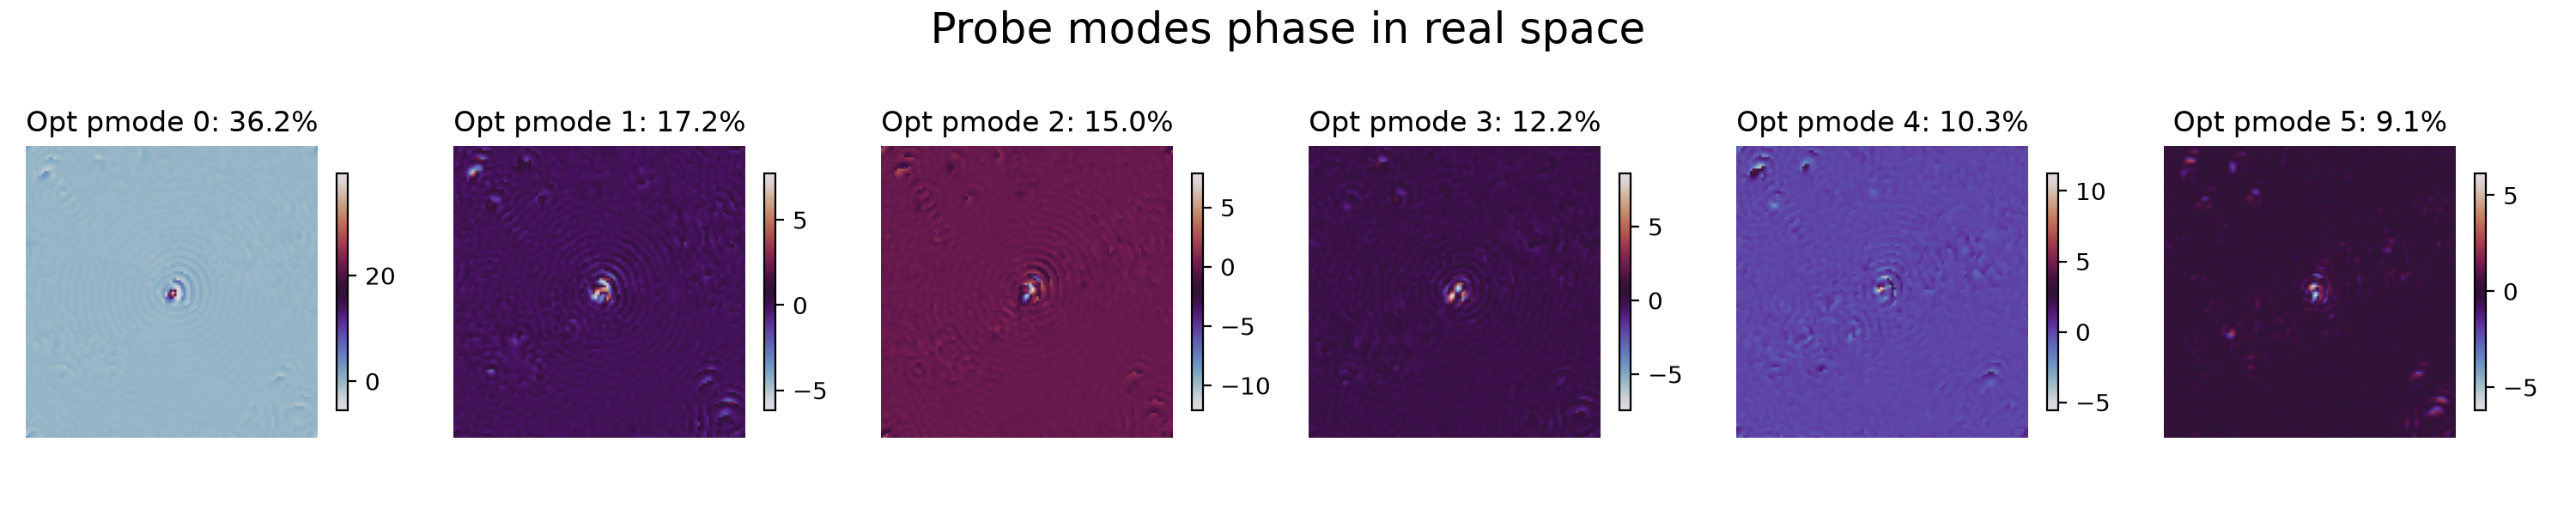

In [23]:
analyzer.plot_probe(space='real',    amp_or_phase='phase')

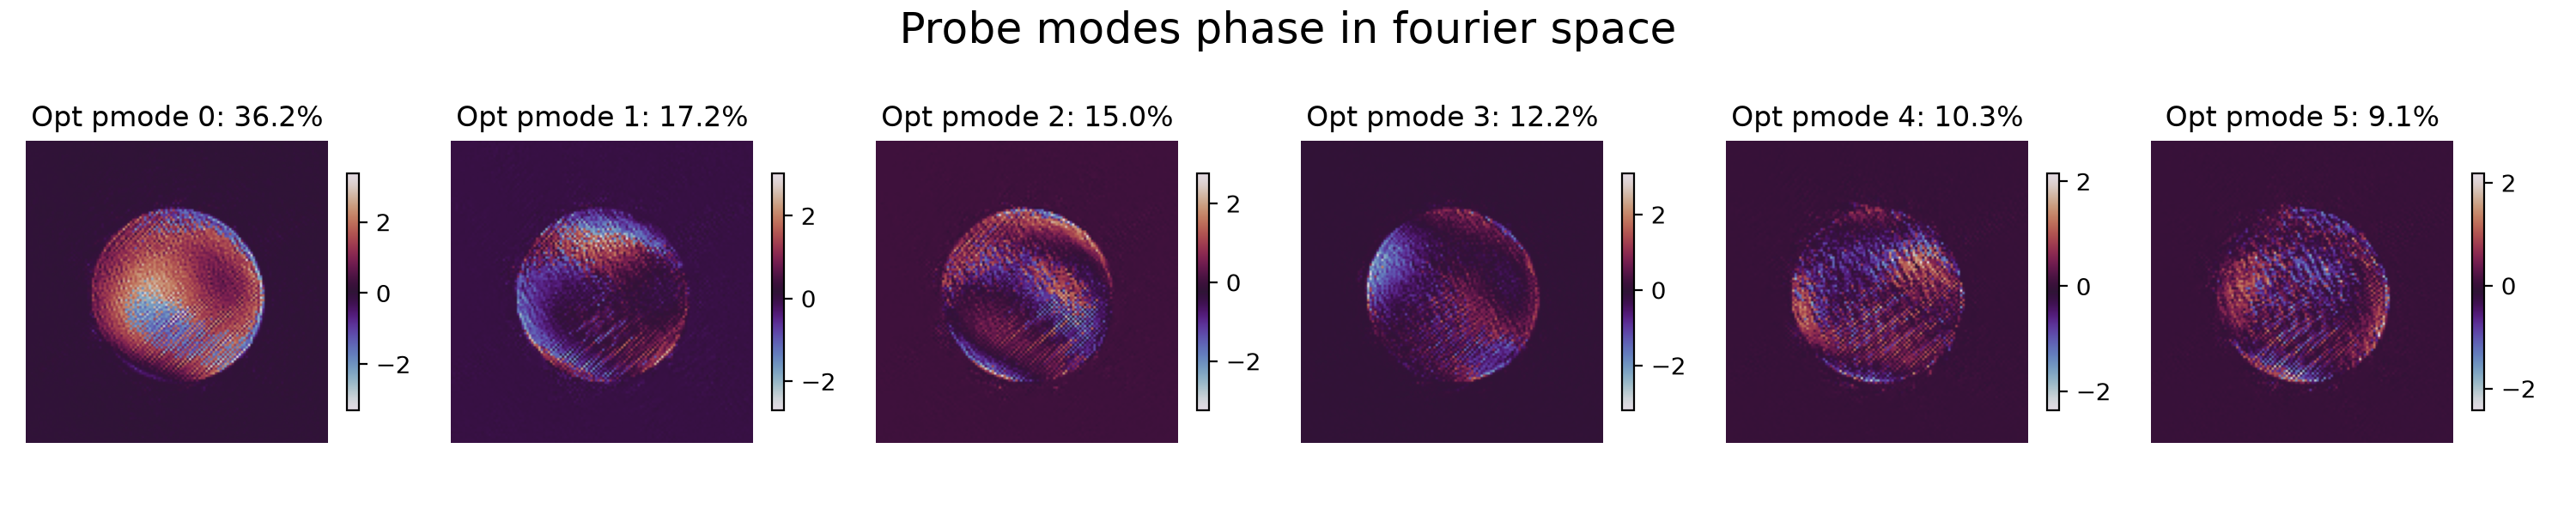

In [24]:
analyzer.plot_probe(space='fourier',    amp_or_phase='phase')

In [26]:
import numpy as np
from scipy.optimize import least_squares


def _electron_wavelength_angstrom(energy_eV):
    """Relativistic electron wavelength in Å."""
    return 12.2639 / np.sqrt(energy_eV * (1.0 + energy_eV / 1_021_998.0))


def FitAberrationReal(ProbeIntensity, dr, beam_energy, semiangle_cutoff):
    """
    Fit low-order aberrations from a centered, coherent real-space probe image.

    Parameters
    ----------
    ProbeIntensity : (ny, nx) array
        Measured probe intensity. The probe should occupy the full simulation
        field of view and be approximately centered.
    dr : float or (float, float)
        Real-space pixel size in Å/pixel. A scalar assumes square pixels.
    beam_energy : float
        Electron kinetic energy in eV, e.g. 80e3.
    semiangle_cutoff : float
        Probe semiangle aperture in mrad.

    Returns
    -------
    dict
        abTEM-compatible coefficients, all Cnm values in Å and phi values in rad:
        C10 (defocus convention: defocus = -C10), C12/phi12,
        C21/phi21, C23/phi23, C30 (Cs).
    """
    measured = np.asarray(ProbeIntensity, dtype=float)
    if measured.ndim != 2 or np.any(measured < 0):
        raise ValueError("ProbeIntensity must be a non-negative 2D array.")

    if np.isscalar(dr):
        dy = dx = float(dr)
    else:
        dy, dx = map(float, dr)

    # Normalize so fitted amplitude is independent of dose/exposure.
    measured = np.nan_to_num(measured, nan=0.0)
    measured /= measured.sum()

    ny, nx = measured.shape
    wavelength = _electron_wavelength_angstrom(beam_energy)
    alpha_cutoff = semiangle_cutoff * 1e-3  # mrad -> rad

    # Reciprocal-space coordinates in cycles / Å.
    ky = np.fft.fftfreq(ny, d=dy)[:, None]
    kx = np.fft.fftfreq(nx, d=dx)[None, :]
    k = np.sqrt(kx**2 + ky**2)
    phi = np.arctan2(ky, kx)

    # alpha = lambda * k in the small-angle approximation used by abTEM.
    aperture = (wavelength * k <= alpha_cutoff).astype(float)

    def basis(n, m):
        """Coefficient multiplying Cnm in abTEM's chi expansion."""
        return (
            2.0 * np.pi / wavelength
            * (wavelength * k) ** (n + 1)
            / (n + 1)
        )

    B10 = basis(1, 0)
    B12 = basis(1, 2)
    B21 = basis(2, 1)
    B23 = basis(2, 3)
    B30 = basis(3, 0)

    def simulated_intensity(p):
        # p uses Cartesian amplitudes for anisotropic terms. This is much more
        # stable than directly optimizing Cnm and phi_nm.
        C10, a12, b12, a21, b21, a23, b23 = p

        chi = (
            C10 * B10
            + B12 * (a12 * np.cos(2 * phi) + b12 * np.sin(2 * phi))
            + B21 * (a21 * np.cos(phi) + b21 * np.sin(phi))
            + B23 * (a23 * np.cos(3 * phi) + b23 * np.sin(3 * phi))
            #+ C30 * B30
        )

        pupil = aperture * np.exp(-1j * chi)

        probe = np.fft.fftshift(np.fft.ifft2(pupil))
        intensity = np.abs(probe) ** 2
        return intensity / intensity.sum()

    def residual(p):
        # Square-root intensity produces a less center-dominated fit.
        return (np.sqrt(simulated_intensity(p)) - np.sqrt(measured)).ravel()

    # Units are Å for all Cnm coefficients; translations are Å.
    # Adjust bounds for a particular instrument if needed.
    initial = np.zeros(7)
    lower = np.array(
        [-1e4, -2e4, -2e4, -2e4, -2e4, -2e4, -2e4]
    )
    upper = np.array(
        [ 1e4,  2e4,  2e4,  2e4,  2e4,  2e4,  2e4]
    )

    result = least_squares(
        residual, initial, bounds=(lower, upper), loss="soft_l1"
    )

    C10, a12, b12, a21, b21, a23, b23= result.x

    def polar(a, b, m):
        return np.hypot(a, b), np.arctan2(b, a) / m

    C12, phi12 = polar(a12, b12, 2)
    C21, phi21 = polar(a21, b21, 1)
    C23, phi23 = polar(a23, b23, 3)

    return {
        "C10": C10,
        "defocus": -C10,
        "C12": C12, "phi12": phi12,
        "C21": C21, "phi21": phi21,
        "C23": C23, "phi23": phi23,
        #"C30": C30,
        #"Cs": C30,
        #"probe_shift_x_A": dx0,
        #"probe_shift_y_A": dy0,
        "cost": result.cost,
        "success": result.success,
        "message": result.message,
        "fitted_intensity": simulated_intensity(result.x),
    }

In [27]:
fit = FitAberrationReal(
    ProbeIntensity=np.abs(probe[0]**2),
    dr=0.2630 ,                 # Å/pixel
    beam_energy=200e3,       # eV
    semiangle_cutoff=26.8,   # mrad
)

print(fit["defocus"],'\n', 
      fit["C12"], np.degrees(fit["phi12"]),
      '\n', 
      fit["C21"], np.degrees(fit["phi21"]),
      '\n',
      fit["C23"], np.degrees(fit["phi23"]), 
      #'\n',
      #fit["C30"]
      )

-2.857505761432955 
 109.8999387100177 26.44568193026278 
 1560.2816174773836 -14.16367530096005 
 506.80278038420096 -21.850215690593036


In [28]:
fit

{'C10': np.float64(2.857505761432955),
 'defocus': np.float64(-2.857505761432955),
 'C12': np.float64(109.8999387100177),
 'phi12': np.float64(0.4615642226182549),
 'C21': np.float64(1560.2816174773836),
 'phi21': np.float64(-0.24720276818515163),
 'C23': np.float64(506.80278038420096),
 'phi23': np.float64(-0.38135820607177506),
 'cost': np.float64(0.20803385094321136),
 'success': True,
 'message': '`ftol` termination condition is satisfied.',
 'fitted_intensity': array([[2.70420055e-07, 1.42735188e-08, 1.13239795e-07, ...,
         1.33582102e-07, 1.35777698e-07, 8.73520869e-08],
        [1.59328019e-07, 7.80663072e-09, 1.24678206e-07, ...,
         1.43892138e-07, 1.71013196e-07, 7.17711812e-08],
        [8.02282233e-08, 3.00880655e-08, 1.63168489e-08, ...,
         4.94819617e-08, 6.56544557e-09, 7.64357143e-09],
        ...,
        [2.32722116e-08, 2.32276095e-08, 2.32696628e-08, ...,
         6.12528860e-08, 2.78530019e-08, 3.52563232e-09],
        [2.42298091e-07, 5.48591789e-

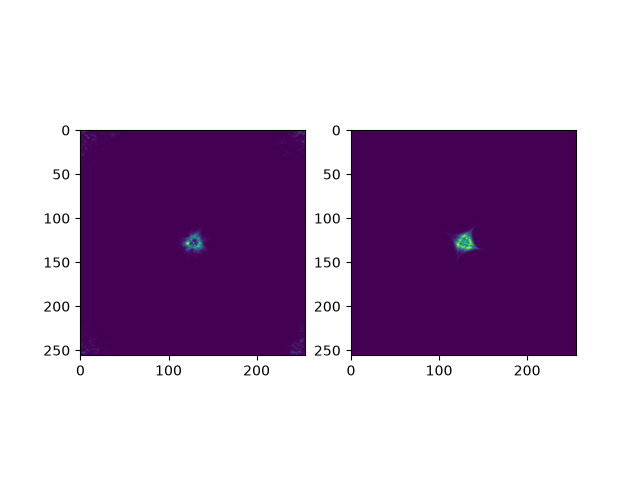

In [29]:
_, axs = plt.subplots(1,2)
axs[0].imshow(np.abs(probe[0])**2)
axs[1].imshow(fit["fitted_intensity"])
plt.show()

In [30]:
fit

{'C10': np.float64(2.857505761432955),
 'defocus': np.float64(-2.857505761432955),
 'C12': np.float64(109.8999387100177),
 'phi12': np.float64(0.4615642226182549),
 'C21': np.float64(1560.2816174773836),
 'phi21': np.float64(-0.24720276818515163),
 'C23': np.float64(506.80278038420096),
 'phi23': np.float64(-0.38135820607177506),
 'cost': np.float64(0.20803385094321136),
 'success': True,
 'message': '`ftol` termination condition is satisfied.',
 'fitted_intensity': array([[2.70420055e-07, 1.42735188e-08, 1.13239795e-07, ...,
         1.33582102e-07, 1.35777698e-07, 8.73520869e-08],
        [1.59328019e-07, 7.80663072e-09, 1.24678206e-07, ...,
         1.43892138e-07, 1.71013196e-07, 7.17711812e-08],
        [8.02282233e-08, 3.00880655e-08, 1.63168489e-08, ...,
         4.94819617e-08, 6.56544557e-09, 7.64357143e-09],
        ...,
        [2.32722116e-08, 2.32276095e-08, 2.32696628e-08, ...,
         6.12528860e-08, 2.78530019e-08, 3.52563232e-09],
        [2.42298091e-07, 5.48591789e-

In [31]:
"""
STEM probe simulation via the contrast transfer function (CTF).

Follows the conventions used in the abTEM walkthrough on the contrast
transfer function:
https://abtem.github.io/doc/user_guide/walkthrough/contrast_transfer_function.html

Aberration function (polar form, aberrations up to 3rd radial order n=3):

    chi(k, phi) = (2*pi/lambda) * sum_{n,m} [1/(n+1)] * C_{n,m} * (k*lambda)^(n+1)
                  * cos(m * (phi - phi_{n,m}))

which, writing alpha = k*lambda (scattering semiangle, small-angle
approximation alpha ~ sin(alpha)), expands for the terms up to C30 as:

    chi(alpha, phi) = (2*pi/lambda) * [
          (1/2) * C10  * alpha^2
        + (1/2) * C12  * alpha^2 * cos(2*(phi - phi12))
        + (1/3) * C21  * alpha^3 * cos(1*(phi - phi21))
        + (1/3) * C23  * alpha^3 * cos(3*(phi - phi23))
        + (1/4) * C30  * alpha^4
    ]

Coefficient reference:
    C10          defocus              [Angstrom]   (Delta_f = -C10)
    C12, phi12   2-fold astigmatism   [Angstrom, rad]
    C21, phi21   coma                 [Angstrom, rad]
    C23, phi23   trefoil              [Angstrom, rad]
    C30          spherical aberration [Angstrom]   (Cs = C30)

The aperture is the hard cutoff used in the walkthrough:

    A(alpha) = 1  if alpha <= semiangle_cutoff
             = 0  otherwise

The probe wave function is obtained as the inverse Fourier transform of
the complex CTF = A(alpha) * exp(-i*chi(alpha, phi)).
"""

import numpy as np


def SimProbe(dr, shape, wavelength, aberration_coefficients, semiangle_cutoff):
    """
    Simulate a STEM probe wave function from the contrast transfer function.

    Parameters
    ----------
    dr : float or (float, float)
        Real-space pixel size (sampling) in Angstrom. A single float is used
        for both x and y; a tuple gives (dx, dy).
    shape : (int, int)
        Number of grid points (Nx, Ny) of the simulation.
    wavelength : float
        Electron wavelength in Angstrom.
    aberration_coefficients : dict
        Aberration coefficients up to 3rd order (C30). Recognized keys
        (all default to 0 if omitted):
            'C10'                 defocus [Angstrom]
            'C12', 'phi12'        2-fold astigmatism [Angstrom], angle [rad]
            'C21', 'phi21'        coma [Angstrom], angle [rad]
            'C23', 'phi23'        trefoil [Angstrom], angle [rad]
            'C30'                 spherical aberration Cs [Angstrom]
    semiangle_cutoff : float
        Objective aperture semiangle cutoff, in milliradians (mrad).

    Returns
    -------
    probe : ndarray, complex128, shape = `shape`
        Real-space probe wave function, fftshifted so the probe is
        centered in the array. Normalized to unit total intensity
        (sum(|probe|**2) == 1).
    """
    Nx, Ny = shape

    if np.isscalar(dr):
        dx = dy = float(dr)
    else:
        dx, dy = dr

    # reciprocal-space grid (1/Angstrom)
    kx = np.fft.fftfreq(Nx, d=dx)
    ky = np.fft.fftfreq(Ny, d=dy)
    kx, ky = np.meshgrid(kx, ky, indexing="ij")

    k = np.sqrt(kx**2 + ky**2)
    phi = np.arctan2(ky, kx)

    # scattering semiangle (radians), small-angle approx: alpha ~ k*lambda
    alpha = k * wavelength

    # --- hard aperture ---
    cutoff = semiangle_cutoff * 1e-3  # mrad -> rad
    aperture = (alpha <= cutoff).astype(np.float64)

    # --- aberration coefficients (defaults to 0) ---
    c = aberration_coefficients
    C10 = c.get("C10", 0.0)
    C12, phi12 = c.get("C12", 0.0), c.get("phi12", 0.0)
    C21, phi21 = c.get("C21", 0.0), c.get("phi21", 0.0)
    C23, phi23 = c.get("C23", 0.0), c.get("phi23", 0.0)
    C30 = c.get("C30", 0.0)

    # --- aberration function chi(alpha, phi), up to C30 ---
    chi = (
        0.5 * C10 * alpha**2
        + 0.5 * C12 * alpha**2 * np.cos(2 * (phi - phi12))
        + (1.0 / 3.0) * C21 * alpha**3 * np.cos(1 * (phi - phi21))
        + (1.0 / 3.0) * C23 * alpha**3 * np.cos(3 * (phi - phi23))
        + 0.25 * C30 * alpha**4
    )
    chi *= 2 * np.pi / wavelength

    # --- complex CTF and real-space probe ---
    ctf = aperture * np.exp(-1j * chi)

    probe = np.fft.ifft2(ctf)
    probe = np.fft.fftshift(probe)

    norm = np.sqrt(np.sum(np.abs(probe) ** 2))
    if norm > 0:
        probe = probe / norm

    return probe


if __name__ == "__main__":
    # quick smoke test / demo
    probe = SimProbe(
        dr=0.05,
        shape=(256, 256),
        wavelength=0.0251,  # ~200 keV, Angstrom
        aberration_coefficients={"C10": 50.0, "C30": 1.0e6},  # defocus, Cs in A
        semiangle_cutoff=20.0,  # mrad
    )
    print("probe shape:", probe.shape)
    print("total intensity:", np.sum(np.abs(probe) ** 2))
    print("peak intensity:", np.abs(probe).max() ** 2)


probe shape: (256, 256)
total intensity: 1.0000000000000002
peak intensity: 0.00017655017451174214


In [32]:
probe = analyzer.get_probe(space='real')


In [33]:
"""
STEM probe simulation via the contrast transfer function (CTF).

Follows the conventions used in the abTEM walkthrough on the contrast
transfer function:
https://abtem.github.io/doc/user_guide/walkthrough/contrast_transfer_function.html

Aberration function (polar form, aberrations up to 3rd radial order n=3):

    chi(k, phi) = (2*pi/lambda) * sum_{n,m} [1/(n+1)] * C_{n,m} * (k*lambda)^(n+1)
                  * cos(m * (phi - phi_{n,m}))

which, writing alpha = k*lambda (scattering semiangle, small-angle
approximation alpha ~ sin(alpha)), expands for the terms up to C30 as:

    chi(alpha, phi) = (2*pi/lambda) * [
          (1/2) * C10  * alpha^2
        + (1/2) * C12  * alpha^2 * cos(2*(phi - phi12))
        + (1/3) * C21  * alpha^3 * cos(1*(phi - phi21))
        + (1/3) * C23  * alpha^3 * cos(3*(phi - phi23))
        + (1/4) * C30  * alpha^4
    ]

Coefficient reference:
    C10          defocus              [Angstrom]   (Delta_f = -C10)
    C12, phi12   2-fold astigmatism   [Angstrom, rad]
    C21, phi21   coma                 [Angstrom, rad]
    C23, phi23   trefoil              [Angstrom, rad]
    C30          spherical aberration [Angstrom]   (Cs = C30)

The aperture is the hard cutoff used in the walkthrough:

    A(alpha) = 1  if alpha <= semiangle_cutoff
             = 0  otherwise

The probe wave function is obtained as the inverse Fourier transform of
the complex CTF = A(alpha) * exp(-i*chi(alpha, phi)).
"""

import numpy as np
from scipy import constants
from scipy.ndimage import center_of_mass, shift as ndi_shift
from scipy.optimize import least_squares


def energy2wavelength(kV):
    """
    Relativistic electron wavelength.

    Parameters
    ----------
    kV : float
        Beam energy in kilovolts (electron acceleration voltage).

    Returns
    -------
    wavelength : float
        Electron wavelength in Angstrom.
    """
    V = kV * 1e3  # volts
    E = constants.e * V  # kinetic energy, Joules
    m0c2 = constants.m_e * constants.c**2
    wavelength_m = constants.h / np.sqrt(2 * constants.m_e * E * (1 + E / (2 * m0c2)))
    return wavelength_m * 1e10  # meters -> Angstrom


def SimProbe(dr, shape, wavelength, aberration_coefficients, semiangle_cutoff):
    """
    Simulate a STEM probe wave function from the contrast transfer function.

    Parameters
    ----------
    dr : float or (float, float)
        Real-space pixel size (sampling) in Angstrom. A single float is used
        for both x and y; a tuple gives (dx, dy).
    shape : (int, int)
        Number of grid points (Nx, Ny) of the simulation.
    wavelength : float
        Electron wavelength in Angstrom.
    aberration_coefficients : dict
        Aberration coefficients up to 3rd order (C30). Recognized keys
        (all default to 0 if omitted):
            'C10'                 defocus [Angstrom]
            'C12', 'phi12'        2-fold astigmatism [Angstrom], angle [rad]
            'C21', 'phi21'        coma [Angstrom], angle [rad]
            'C23', 'phi23'        trefoil [Angstrom], angle [rad]
            'C30'                 spherical aberration Cs [Angstrom]
    semiangle_cutoff : float
        Objective aperture semiangle cutoff, in milliradians (mrad).

    Returns
    -------
    probe : ndarray, complex128, shape = `shape`
        Real-space probe wave function, fftshifted so the probe is
        centered in the array. Normalized to unit total intensity
        (sum(|probe|**2) == 1).
    """
    Nx, Ny = shape

    if np.isscalar(dr):
        dx = dy = float(dr)
    else:
        dx, dy = dr

    # reciprocal-space grid (1/Angstrom)
    kx = np.fft.fftfreq(Nx, d=dx)
    ky = np.fft.fftfreq(Ny, d=dy)
    kx, ky = np.meshgrid(kx, ky, indexing="ij")

    k = np.sqrt(kx**2 + ky**2)
    phi = np.arctan2(ky, kx)

    # scattering semiangle (radians), small-angle approx: alpha ~ k*lambda
    alpha = k * wavelength

    # --- hard aperture ---
    cutoff = semiangle_cutoff * 1e-3  # mrad -> rad
    aperture = (alpha <= cutoff).astype(np.float64)

    # --- aberration coefficients (defaults to 0) ---
    c = aberration_coefficients
    C10 = c.get("C10", 0.0)
    C12, phi12 = c.get("C12", 0.0), c.get("phi12", 0.0)
    C21, phi21 = c.get("C21", 0.0), c.get("phi21", 0.0)
    C23, phi23 = c.get("C23", 0.0), c.get("phi23", 0.0)
    C30 = c.get("C30", 0.0)

    # --- aberration function chi(alpha, phi), up to C30 ---
    chi = (
        0.5 * C10 * alpha**2
        + 0.5 * C12 * alpha**2 * np.cos(2 * (phi - phi12))
        + (1.0 / 3.0) * C21 * alpha**3 * np.cos(1 * (phi - phi21))
        + (1.0 / 3.0) * C23 * alpha**3 * np.cos(3 * (phi - phi23))
        + 0.25 * C30 * alpha**4
    )
    chi *= 2 * np.pi / wavelength

    # --- complex CTF and real-space probe ---
    ctf = aperture * np.exp(-1j * chi)

    probe = np.fft.ifft2(ctf)
    probe = np.fft.fftshift(probe)

    norm = np.sqrt(np.sum(np.abs(probe) ** 2))
    if norm > 0:
        probe = probe / norm

    return probe


# --- internal Cartesian parametrization for fitting -------------------------
#
# The (C_m, phi_m) polar form of each non-isotropic aberration term is
# awkward to fit directly with a gradient-based optimizer because phi_m is
# periodic and the term is degenerate at C_m = 0 (phi_m undefined). Instead
# the optimizer works on the equivalent Cartesian components
#
#     C_m * cos(m*(phi - phi_m)) = a_m * cos(m*phi) + b_m * sin(m*phi)
#
# with a_m = C_m*cos(m*phi_m), b_m = C_m*sin(m*phi_m), which are smooth,
# unconstrained, and free of the phi_m periodicity/degeneracy. C10 and C30
# (m=0, isotropic) need no such treatment.
#
# Fit vector: x = [C10, C30, a12, b12, a21, b21, a23, b23]

_PARAM_NAMES = ["C10", "C30", "a12", "b12", "a21", "b21", "a23", "b23"]


def _coeffs_to_x(coeffs):
    """Physical (C, phi) dict -> Cartesian fit vector."""
    C10 = coeffs.get("C10", 0.0)
    C30 = coeffs.get("C30", 0.0)
    C12, phi12 = coeffs.get("C12", 0.0), coeffs.get("phi12", 0.0)
    C21, phi21 = coeffs.get("C21", 0.0), coeffs.get("phi21", 0.0)
    C23, phi23 = coeffs.get("C23", 0.0), coeffs.get("phi23", 0.0)
    return np.array(
        [
            C10,
            C30,
            C12 * np.cos(2 * phi12),
            C12 * np.sin(2 * phi12),
            C21 * np.cos(phi21),
            C21 * np.sin(phi21),
            C23 * np.cos(3 * phi23),
            C23 * np.sin(3 * phi23),
        ]
    )


def _x_to_coeffs(x):
    """Cartesian fit vector -> physical (C, phi) dict, for SimProbe / reporting."""
    C10, C30, a12, b12, a21, b21, a23, b23 = x
    C12 = np.hypot(a12, b12)
    C21 = np.hypot(a21, b21)
    C23 = np.hypot(a23, b23)
    phi12 = (np.arctan2(b12, a12) / 2) % np.pi
    phi21 = np.arctan2(b21, a21) % (2 * np.pi)
    phi23 = (np.arctan2(b23, a23) / 3) % (2 * np.pi / 3)
    return {
        "C10": C10,
        "C12": C12,
        "phi12": phi12,
        "C21": C21,
        "phi21": phi21,
        "C23": C23,
        "phi23": phi23,
        "C30": C30,
    }


def _recenter_intensity(intensity):
    """Shift an intensity image so its centroid sits on the array center."""
    shape = intensity.shape
    center = np.array([(n - 1) / 2.0 for n in shape])
    com = np.array(center_of_mass(intensity))
    return ndi_shift(intensity, center - com, mode="constant", cval=0.0)


def _natural_scales(wavelength, semiangle_cutoff):
    """
    Characteristic magnitude of each Cartesian fit parameter: the
    coefficient value that gives ~1 radian of aberration phase at the
    aperture edge, i.e. C_scale(n) = (n+1) * lambda / alpha_max**(n+1).

    Used both as `x_scale` (trust-region scaling) and as the finite-
    difference step base for `least_squares`. This matters a lot here:
    at the perfectly-round (unaberrated) probe, the probe INTENSITY is
    stationary to first order in every aberration coefficient (adding a
    small aberration only perturbs the phase of the wave function), so
    the naive default step (relative to the current parameter value,
    which is degenerate at x=0) sees a numerically zero gradient and the
    optimizer never moves. Stepping by an amount comparable to one
    radian of phase avoids that degenerate point.
    """
    alpha_max = semiangle_cutoff * 1e-3  # mrad -> rad
    scale1 = 2 * wavelength / alpha_max**2       # n=1: C10, C12
    scale2 = 3 * wavelength / alpha_max**3       # n=2: C21, C23
    scale3 = 4 * wavelength / alpha_max**4       # n=3: C30
    # order matches _PARAM_NAMES: C10, C30, a12, b12, a21, b21, a23, b23
    return np.array([scale1, scale3, scale1, scale1, scale2, scale2, scale2, scale2])


def FitAberrations(
    ProbeIntensity,
    dr,
    kV,
    semiangle_cutoff,
    initial_coefficients=None,
    recenter=True,
    n_restarts=8,
    seed=0,
    max_nfev=300,
):
    """
    Fit aberration coefficients (up to C30) to a measured STEM probe
    intensity, using SimProbe as the forward model.

    This is a nonlinear least-squares fit of the 8 aberration parameters
    (C10, C12, phi12, C21, phi21, C23, phi23, C30) so that
    |SimProbe(...)|**2 matches the (normalized, optionally recentered)
    measured intensity as closely as possible.

    Caveat: recovering aberrations from a *single* probe intensity image
    is a non-convex, and for some terms non-unique, inverse problem (this
    is the classic reason real CTEM/STEM aberration measurement uses a
    through-focal series or a Zemlin tableau of tilted images rather than
    one image). In particular, an unaberrated probe is exactly stationary
    to first order in every coefficient, so the cost landscape has a flat
    saddle at zero aberration; `n_restarts` random restarts (with a
    physically-scaled jitter) are used to help escape this, but a good
    `initial_coefficients` guess (e.g. from the microscope's own corrector
    readout) will converge faster and more reliably than a cold start.
    Even then, expect coma (C21) to come back the least well-constrained
    of the eight parameters: its effect on a single, on-axis probe
    intensity is weak and easily traded off against the other terms at
    low residual cost, which is exactly why real microscopes measure coma
    from a beam-tilt series (Zemlin tableau) rather than a single image.

    Parameters
    ----------
    ProbeIntensity : ndarray, shape (Nx, Ny)
        Measured probe intensity (e.g. from a Ronchigram/vacuum probe image
        or a reconstructed probe). Any positive overall scale is fine — it
        is renormalized internally.
    dr : float or (float, float)
        Real-space pixel size of `ProbeIntensity`, in Angstrom.
    kV : float
        Beam energy in kilovolts; converted to wavelength via
        `energy2wavelength`.
    semiangle_cutoff : float
        Objective aperture semiangle cutoff, in mrad (assumed known, not
        fitted).
    initial_coefficients : dict, optional
        Starting guess, same keys as `SimProbe`'s `aberration_coefficients`.
        Defaults to a cold start (all zeros) with random restarts.
    recenter : bool, optional
        If True (default), shift `ProbeIntensity` so its centroid matches
        the array center before fitting (SimProbe always returns a
        centered probe, so an off-center measured probe would otherwise
        bias the fit).
    n_restarts : int, optional
        Number of least-squares runs from jittered starting points; the
        lowest-cost result is kept. The first restart always starts
        exactly at `initial_coefficients` (nudged off zero if that is the
        cold-start default).
    seed : int, optional
        Seed for the restart jitter, for reproducibility.
    max_nfev : int, optional
        Maximum number of function evaluations per least-squares run.

    Returns
    -------
    dict with keys:
        'coefficients'      fitted aberration dict (same keys as SimProbe's
                            `aberration_coefficients`)
        'wavelength'        electron wavelength used, in Angstrom
        'fitted_intensity'  simulated probe intensity at the fitted
                            coefficients, normalized to unit sum
        'target_intensity'  the (recentered, normalized) measured intensity
                            actually fit against
        'result'            the best scipy.optimize.OptimizeResult
    """
    shape = ProbeIntensity.shape
    wavelength = energy2wavelength(kV)

    target = np.asarray(ProbeIntensity, dtype=np.float64)
    if recenter:
        target = _recenter_intensity(target)
    target = target / target.sum()

    def residuals(x):
        coeffs = _x_to_coeffs(x)
        probe = SimProbe(dr, shape, wavelength, coeffs, semiangle_cutoff)
        sim_intensity = np.abs(probe) ** 2
        sim_intensity = sim_intensity / sim_intensity.sum()
        return (sim_intensity - target).ravel()

    x_scale = _natural_scales(wavelength, semiangle_cutoff)

    if initial_coefficients is None:
        center = np.zeros(len(_PARAM_NAMES))
        jitter = x_scale
    else:
        center = _coeffs_to_x(initial_coefficients)
        jitter = np.maximum(0.15 * np.abs(center), 0.15 * x_scale)

    rng = np.random.default_rng(seed)
    best = None
    for i in range(max(n_restarts, 1)):
        if i == 0:
            x0 = center if not np.allclose(center, 0) else 0.05 * x_scale
        else:
            x0 = center + rng.uniform(-1.0, 1.0, size=center.shape) * jitter
        result = least_squares(
            residuals, x0, x_scale=x_scale, diff_step=1e-2, max_nfev=max_nfev
        )
        if best is None or result.cost < best.cost:
            best = result

    fitted_coefficients = _x_to_coeffs(best.x)
    fitted_probe = SimProbe(dr, shape, wavelength, fitted_coefficients, semiangle_cutoff)
    fitted_intensity = np.abs(fitted_probe) ** 2
    fitted_intensity = fitted_intensity / fitted_intensity.sum()

    return {
        "coefficients": fitted_coefficients,
        "wavelength": wavelength,
        "fitted_intensity": fitted_intensity,
        "target_intensity": target,
        "result": best,
    }

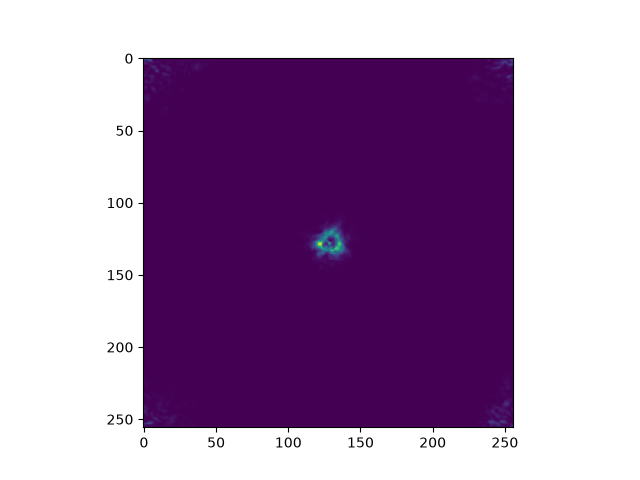

In [34]:
plt.figure()
plt.imshow(np.abs(probe[0])**2)
plt.show()

In [35]:
fit = FitAberrations(
    np.abs(probe[0])**2,
    0.2630,
    200,
    26.8,
    initial_coefficients=None,
    recenter=False,
    n_restarts=8,
    seed=0,
    max_nfev=1000,
)

In [36]:
fit

{'coefficients': {'C10': np.float64(112.10170226731083),
  'C12': np.float64(5.8512234052878425),
  'phi12': np.float64(1.5914925551171486),
  'C21': np.float64(527.0664724278914),
  'phi21': np.float64(1.9155830764052308),
  'C23': np.float64(494.4685646478257),
  'phi23': np.float64(0.8065557370539973),
  'C30': np.float64(19643.739147737673)},
 'wavelength': np.float64(0.025079340436272274),
 'fitted_intensity': array([[1.15605802e-07, 2.95978625e-07, 4.85172461e-10, ...,
         1.06063429e-08, 3.15542384e-07, 1.04974236e-07],
        [3.46682047e-08, 7.26469511e-08, 1.13951557e-09, ...,
         8.37033048e-09, 4.86652290e-08, 2.21980040e-08],
        [5.07992431e-08, 1.20672587e-07, 3.67931350e-09, ...,
         9.67502042e-09, 1.27537400e-07, 3.38917477e-08],
        ...,
        [9.42873093e-08, 1.38111771e-07, 1.10293090e-08, ...,
         2.49150803e-09, 1.88851963e-07, 6.78215822e-08],
        [1.20648165e-07, 2.38850322e-07, 1.25935875e-09, ...,
         1.17656629e-08, 3.

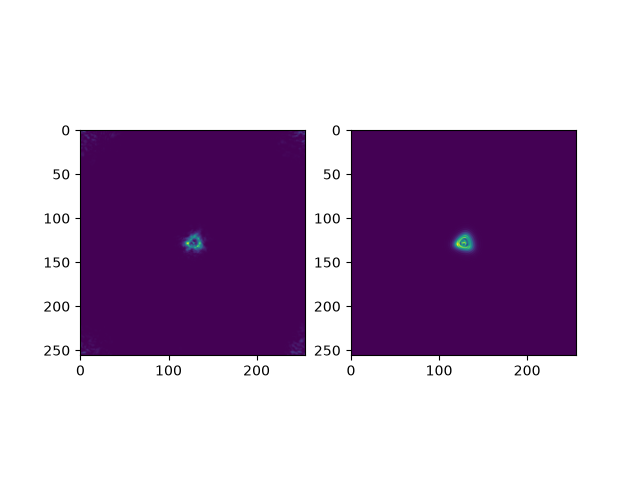

In [38]:
_, axs = plt.subplots(1,2)
axs[0].imshow(np.abs(probe[0])**2)
axs[1].imshow(fit["fitted_intensity"])
plt.show()